In [3]:
# -------------------------
# Part 1: Implement Naive Bayes from Scratch
# -------------------------

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [7]:
from google.colab import files
uploaded = files.upload()

Saving  Mushroom.csv to  Mushroom.csv


In [39]:

# Quick check: count missing (NaN) values in each column
print(df.isnull().sum())


type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64


In [17]:
# target coloum is y
y = df["type"]

# drop the target column and keep all other columns so the model would not cheat
x = df.drop(columns = ["type"])

# fix 20/80 split
x_train, x_test, y_train, y_test = train_test_split (
     x,y, test_size = 0.20, random_state=35, stratify=y )



In [30]:
# -----------------------------------
# Naive Bayes classifier from scratch
# -----------------------------------

class NaiveBayes:

    def __init__(self, alpha=1):
        self.alpha = alpha
        self.classes = []
        self.class_log_prior = {}
        self.feature_log_prob = {}
        self.feature_values = {}

        # extra storage to handle unseen values
        self.class_count = {}         # stores n_c for each class
        self.feature_value_count = {} # stores V for each feature

    def fit(self, X, y):

        # reset index so filtering works correctly
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)

        # get class labels
        self.classes = sorted(y.unique())

        # store possible values for each feature
        for col in X.columns:
            self.feature_values[col] = sorted(X[col].unique())
            self.feature_value_count[col] = len(self.feature_values[col])  # V

        # -------------------------
        # A) class priors
        # -------------------------
        total_samples = len(y)

        for c in self.classes:
            count_c = (y == c).sum()
            self.class_count[c] = count_c   # store n_c
            self.class_log_prior[c] = np.log(count_c / total_samples)

# -------------------------
# Step B: Compute class-conditional probabilities
# Step C: Apply Laplace (add-one) smoothing
# Step D: Use log-probabilities
# Step E: Store computed probabilities
# -------------------------
        for c in self.classes:
            self.feature_log_prob[c] = {}

            X_c = X[y == c]
            n_c = len(X_c)

            for col in X.columns:
                self.feature_log_prob[c][col] = {}

                values = self.feature_values[col]
                V = len(values)

                counts = X_c[col].value_counts()

                for v in values:
                    count_v = counts.get(v, 0)

                    # Laplace smoothing
                    prob = (count_v + self.alpha) / (n_c + self.alpha * V)

                    # store log(prob)
                    self.feature_log_prob[c][col][v] = np.log(prob)

    def predict(self, X):

        X = X.reset_index(drop=True)
        predictions = []

        for _, row in X.iterrows():

            best_class = None
            best_score = -1e100

            for c in self.classes:

                score = self.class_log_prior[c]

                for col in X.columns:
                    value = row[col]

                    # if value seen in training, use stored log prob
                    if value in self.feature_log_prob[c][col]:
                        score += self.feature_log_prob[c][col][value]

                    # if unseen value, use smoothed unseen probability
                    else:
                        n_c = self.class_count[c]
                        V = self.feature_value_count[col]

                        unseen_prob = self.alpha / (n_c + self.alpha * V)
                        score += np.log(unseen_prob)

                if score > best_score:
                    best_score = score
                    best_class = c

            predictions.append(best_class)

        return np.array(predictions)


In [31]:
nb = NaiveBayes(alpha=1)
nb.fit(x_train, y_train)

y_pred = nb.predict(x_test)

accuracy = (y_pred == y_test.to_numpy()).mean()
print("Accuracy:", accuracy)

Accuracy: 1.0


In [32]:
# -------------------------------------------
# Part 2A: Evaluate my Naive Bayes model (manual metrics)
# -------------------------------------------


# y_test is a pandas Series, y_pred is numpy array
y_true = y_test.to_numpy()

# choose which class is "positive" for precision/recall/f1
pos_label = "p"   # poisonous (common in mushroom dataset)

# confusion matrix manually: rows=true, cols=pred
labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
label_to_i = {lab: i for i, lab in enumerate(labels)}

cm = np.zeros((len(labels), len(labels)), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[label_to_i[t], label_to_i[p]] += 1

# accuracy
accuracy = (y_pred == y_true).mean()

# binary precision/recall/f1 for pos_label
# TP: true=pos and pred=pos, etc.
tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
fn = np.sum((y_true == pos_label) & (y_pred != pos_label))

precision = tp / (tp + fp) if (tp + fp) != 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) != 0 else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0.0

print("---- Part 2A: My Naive Bayes ----")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 score :", f1)

print("\nConfusion Matrix (rows=true, cols=pred)")
print("labels order:", labels)
print(cm)


---- Part 2A: My Naive Bayes ----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 score : 1.0

Confusion Matrix (rows=true, cols=pred)
labels order: ['e', 'p']
[[1 0]
 [0 1]]


In [33]:
# -------------------------------------------
# Part 2B: Compare with sklearn CategoricalNB (same split)
# -------------------------------------------


from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

pos_label = "p"  # poisonous
labels = ["e", "p"]

X_train_enc = x_train.copy()
X_test_enc  = x_test.copy()

# store number of categories for each feature (and add 1 for unknown)
min_cats = []

for col in X_train_enc.columns:
    cats = pd.Categorical(X_train_enc[col]).categories
    V = len(cats)

    # encode train
    train_codes = pd.Categorical(X_train_enc[col], categories=cats).codes
    X_train_enc[col] = train_codes

    # encode test (unknown becomes -1)
    test_codes = pd.Categorical(X_test_enc[col], categories=cats).codes

    # map unknown (-1) to the last index (V)
    test_codes = np.where(test_codes == -1, V, test_codes)
    X_test_enc[col] = test_codes

    # tell sklearn there are V+1 categories for this feature
    min_cats.append(V + 1)

# Train sklearn NB with correct category sizes
sk_nb = CategoricalNB(alpha=1.0, min_categories=min_cats)
sk_nb.fit(X_train_enc, y_train)

sk_pred = sk_nb.predict(X_test_enc)

print("---- Part 2B: sklearn CategoricalNB ----")
print("Accuracy :", accuracy_score(y_test, sk_pred))
print("Precision:", precision_score(y_test, sk_pred, pos_label=pos_label))
print("Recall   :", recall_score(y_test, sk_pred, pos_label=pos_label))
print("F1 score :", f1_score(y_test, sk_pred, pos_label=pos_label))

print("\nConfusion Matrix (rows=true, cols=pred)")
print(confusion_matrix(y_test, sk_pred, labels=labels))

---- Part 2B: sklearn CategoricalNB ----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 score : 1.0

Confusion Matrix (rows=true, cols=pred)
[[1 0]
 [0 1]]


In [ ]:
# ---------------------------

# Part 2C: Comparison


# 1. Are the predictions identical or different?
The predictions from my Naive Bayes implementation and sklearn’s CategoricalNB are identical on the test set.
The fraction of identical predictions is 1.0, meaning both models predicted the same class for every test sample.


# 2. If they differ, explain why this might happen.
In this case, the predictions do not differ.
This is because both models use the same training and test split, the same Laplace smoothing parameter (alpha = 1),
and the same Naive Bayes probability rule using log-probabilities.
Therefore, both implementations produce the same classification decisions.

#---------------------------#

Training size = 20% (1 samples)  |  Accuracy = 0.5000
Training size = 40% (3 samples)  |  Accuracy = 1.0000
Training size = 60% (4 samples)  |  Accuracy = 1.0000
Training size = 80% (6 samples)  |  Accuracy = 1.0000
Training size = 100% (8 samples)  |  Accuracy = 1.0000


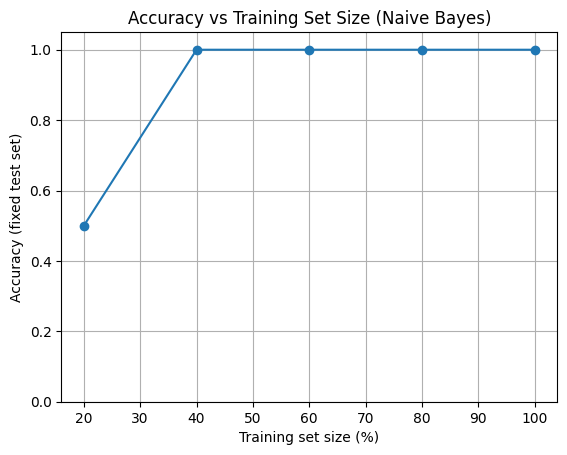

In [34]:

# -------------------------
# Bonus: Train with different fractions of the training set 20%, 40%, 60%, 80%, and 100%.
# -------------------------

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
accuracies = []

# keep test set fixed
X_test_fixed = x_test.reset_index(drop=True)
y_test_fixed = y_test.reset_index(drop=True)

# reset train indices (makes sampling easier)
X_train_full = x_train.reset_index(drop=True)
y_train_full = y_train.reset_index(drop=True)

n_train = len(X_train_full)

# fixed seed so results are reproducible
np.random.seed(35)

for frac in fractions:
    # number of training samples to use
    k = int(frac * n_train)

    # pick a random subset of the training data
    subset_idx = np.random.choice(n_train, size=k, replace=False)

    X_sub = X_train_full.iloc[subset_idx].reset_index(drop=True)
    y_sub = y_train_full.iloc[subset_idx].reset_index(drop=True)

    # train from-scratch Naive Bayes on the subset
    nb_small = NaiveBayes(alpha=1)
    nb_small.fit(X_sub, y_sub)

    # evaluate accuracy on the fixed test set
    pred = nb_small.predict(X_test_fixed)
    acc = (pred == y_test_fixed.to_numpy()).mean()

    accuracies.append(acc)

    print(f"Training size = {int(frac*100)}% ({k} samples)  |  Accuracy = {acc:.4f}")

# -------------------------
# Plot: Accuracy vs training set size
# -------------------------
plt.figure()
plt.plot([f*100 for f in fractions], accuracies, marker='o')
plt.xlabel("Training set size (%)")
plt.ylabel("Accuracy (fixed test set)")
plt.title("Accuracy vs Training Set Size (Naive Bayes)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


In [38]:

# Load the provided input file
inp = pd.read_csv(" Mushroom.csv")

# If the file contains labels, remove them before prediction
if "type" in inp.columns:
    X_in = inp.drop(columns=["type"])
else:
    X_in = inp

# Use your trained from-scratch model
preds = nb.predict(X_in)

# Save predictions to required output file
out = pd.DataFrame({"prediction": preds})
out.to_csv("output_mushroom_input.csv", index=False)

print("Saved output_mushroom.csv")


Saved output_mushroom.csv
